<a href="https://colab.research.google.com/github/victoriaelena102/-Proiect_Econometrie_Avansata_Walmart_Sales_Forecast_Andrei_Maria-Bezuscu_Victoria/blob/main/Proiect_Econometrie_Avansata_Walmart_Sales_Forecast_Andrei_Maria%2BBezuscu_Victoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proiect Econometrie Avansata :Walmart Sales Forecast-Andrei Maria si Bezuscu Victoria

•În sectorul retail, prognozarea cererii reprezintă un element strategic fundamental, contribuind la optimizarea stocurilor, eficientizarea lanțului de aprovizionare, planificarea campaniilor promoționale și creșterea profitabilității organizaționale.

•Scopul principal al cercetării este identificarea factorilor care influențează nivelul vânzărilor și construirea unor modele predictive capabile să estimeze cât mai precis evoluția acestora.



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [ ]:
features = pd.read_csv("features.csv")
train = pd.read_csv("train.csv")

df = pd.merge(
    train,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,9


In [ ]:
# Primele rânduri ale datasetului
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,9


Datasetul conține aproximativ 421.570 observații și 17 variabile.

Variabila dependentă a modelului este Weekly_Sales, aceasta reprezentând nivelul vânzărilor săptămânale pentru fiecare departament și magazin.

Variabilele explicate utilizate în model:

•	Store = ID-ul magazinului Walmart

•	Dept = Departamentul magazinului

•	Date = Data săptămânii

•	Weekly_Sales = Vânzările săptămânale

•	Temperature = Temperatura medie din regiune

•	Fuel_Price = Prețul combustibilului

•	CPI = Indicatorul privind perioadele de sărbătoare

•	Unemployment = Rata șomajului

•	IsHoliday = Indică dacă perioada conține sărbători

•	MarkDown1-5 = Variabile anonimizate despre promoții și reduceri

•	Year = An extras din dată

•	Month = Lună extrasă din dată

•	Week = Numărul săptămânii


In [ ]:
# Informații generale despre coloane și tipuri de date
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Year          421570 non-null  int32         
 15  Month         421

Analiza exploratorie a datelor

În această etapă sunt analizate distribuțiile variabilelor și relațiile dintre acestea pentru a înțelege mai bine structura datasetului și factorii care influențează vânzările.

In [ ]:
# Statistici descriptive
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,2010.968591,6.449510,25.826762
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,2010.000000,4.000000,14.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,2011.000000,6.000000,26.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,2012.000000,9.000000,38.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000,52.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,0.796876,3.243217,14.151887


Nivelul mediu al vânzărilor săptămânale este de aproximativ 15.981 unități monetare, însă mediana (50%) este considerabil mai redusă, ceea ce confirmă existența unei distribuții asimetrice spre dreapta și prezența unor valori extreme ridicate.

Diferența semnificativă dintre quartila superioară și valoarea maximă sugerează existența unor perioade comerciale excepționale, caracterizate prin niveluri foarte ridicate ale cererii, posibil asociate cu promoții sau evenimente sezoniere.



În cazul variabilelor promoționale MarkDown1–MarkDown5, se observă existența unor variații foarte mari între valori minime și maxime, ceea ce indică intensități diferite ale campaniilor promoționale desfășurate în cadrul magazinelor Walmart.


Indicatorii economici precum CPI și Unemployment prezintă variații moderate pe perioada analizată, sugerând existența unor schimbări macroeconomice care pot influența comportamentul consumatorilor și nivelul cererii.


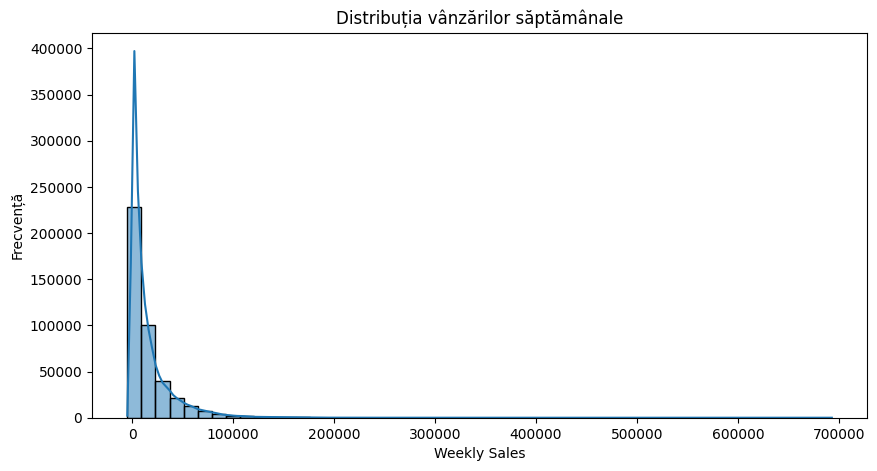

In [ ]:
# Distribuția vânzărilor săptămânale
plt.figure(figsize=(10, 5))
sns.histplot(df["Weekly_Sales"], bins=50, kde=True)
plt.title("Distribuția vânzărilor săptămânale")
plt.xlabel("Weekly Sales")
plt.ylabel("Frecvență")
plt.show()

Distribuția datelor evidențiază prezența unei asimetrii pozitive pronunțate, ceea ce indică faptul că majoritatea observațiilor sunt concentrate în zona valorilor reduse și medii ale vânzărilor, în timp ce un număr restrâns de observații înregistrează niveluri semnificativ mai ridicate ale acestora.

 Această structură a distribuției sugerează existența unor diferențe semnificative între magazine, departamente și perioade comerciale. Valorile extreme pot fi asociate cu perioade promoționale intense, evenimente comerciale majore sau intervale festive caracterizate prin creșteri accentuate ale cererii.

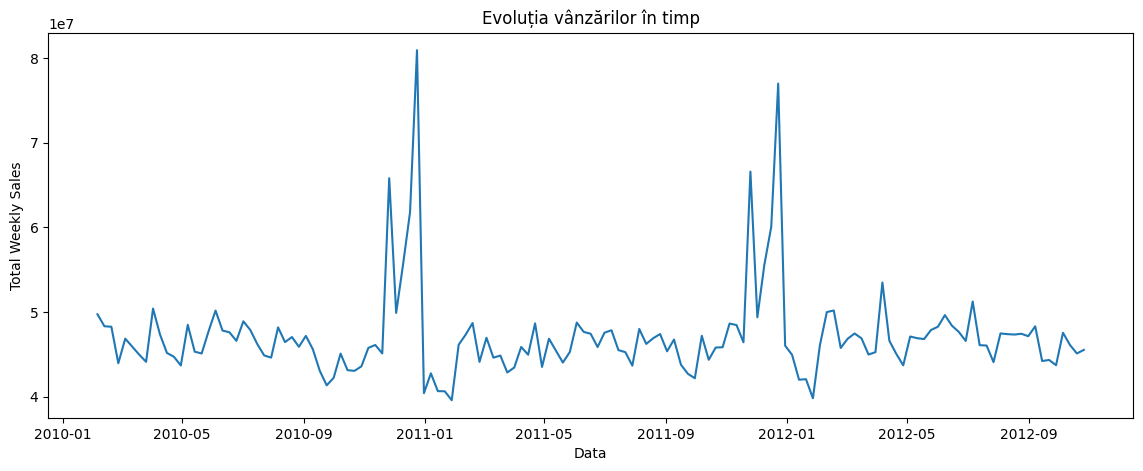

In [ ]:
# Evoluția vânzărilor în timp
sales_by_date = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(sales_by_date)
plt.title("Evoluția vânzărilor în timp")
plt.xlabel("Data")
plt.ylabel("Total Weekly Sales")
plt.show()

Evoluția în timp a vânzărilor Walmart evidențiază existența unor fluctuații periodice și a unor variații semnificative ale nivelului cererii de-a lungul intervalului analizat.

Prezența unor vârfuri pronunțate ale vânzărilor sugerează existența unor componente sezoniere și calendaristice importante, asociate în principal cu perioade festive, campanii promoționale sau modificări ale comportamentului consumatorilor.

Pentru captarea efectelor sezoniere și temporale au fost introduse variabile suplimentare precum:Week,Month,Year.

Integrarea acestor variabile în procesul de modelare permite surprinderea influențelor sezoniere asupra dinamicii vânzărilor și contribuie la îmbunătățirea performanței predictive a modelelor utilizate.


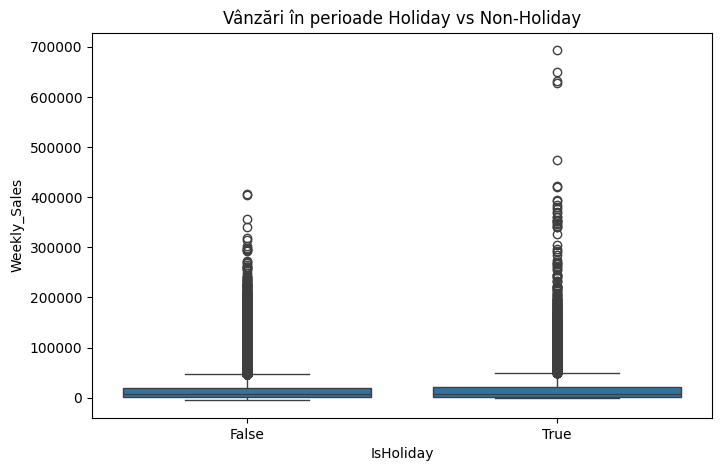

In [ ]:
# Vânzări în perioade holiday vs non-holiday
plt.figure(figsize=(8, 5))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Vânzări în perioade Holiday vs Non-Holiday")
plt.show()

Graficul de tip boxplot evidențiază distribuția vânzărilor săptămânale în funcție de existența perioadelor de sărbători (IsHoliday).
Se observă că în perioadele holiday (True) nivelul vânzărilor este, în general, mai ridicat comparativ cu perioadele non-holiday (False). În plus, distribuția valorilor este considerabil mai dispersată în timpul sărbătorilor, ceea ce sugerează o volatilitate mai mare a comportamentului consumatorilor.

Prezența unui număr ridicat de valori extreme în categoria holiday indică existența unor perioade cu creșteri semnificative ale cererii. Aceste creșteri pot fi explicate prin:

•	promoții sezoniere;

•	campanii comerciale intensive;

•	creșterea consumului în perioade festive;

•	modificarea comportamentului de cumpărare al consumatorilor.

  
  Dispersia ridicată a valorilor arată că efectul sărbătorilor nu este uniform pentru toate magazinele și departamentele, ceea ce sugerează existența unor diferențe structurale între unitățile comerciale analizate.

  Rezultatele obținute confirmă faptul că variabila IsHoliday reprezintă un predictor relevant pentru estimarea vânzărilor și justifică includerea acesteia în modelele predictive dezvoltate în cadrul proiectului.


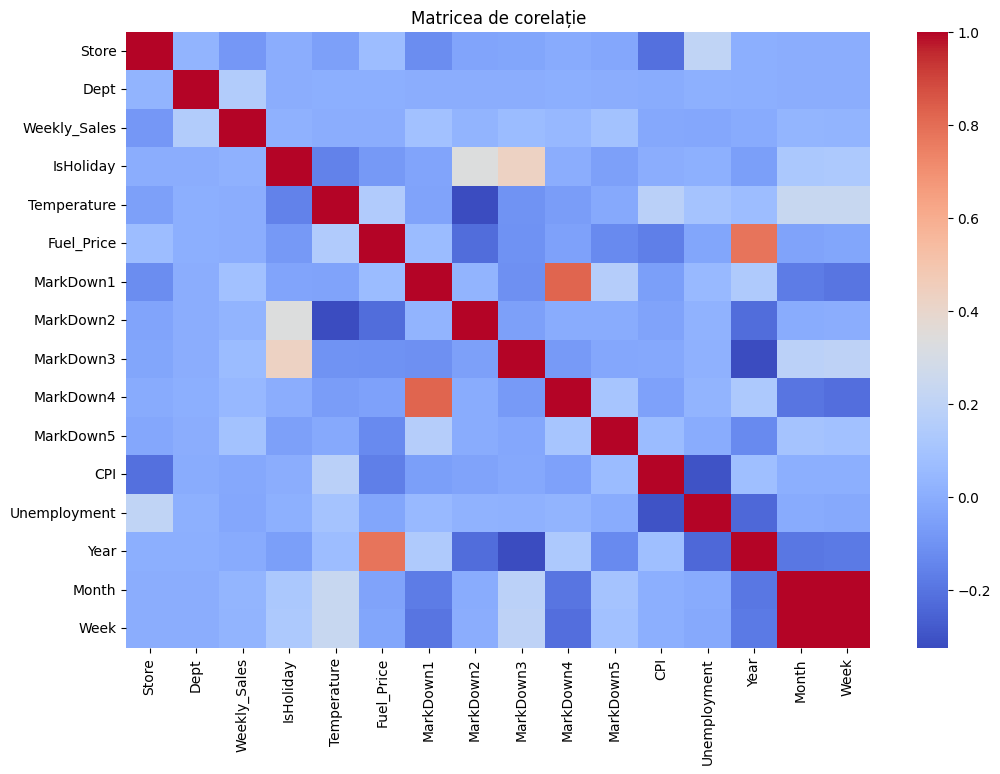

In [ ]:
# Matricea de corelație
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matricea de corelație")
plt.show()

Matricea de corelație evidențiază relațiile dintre variabilele numerice incluse în dataset și permite evaluarea intensității și direcției asocierilor dintre acestea.

Valorile apropiate de 1 indică o corelație pozitivă puternică, cele apropiate de -1 o corelație negativă puternică, iar valorile apropiate de 0 sugerează o relație liniară slabă sau inexistentă.

Variabila dependentă Weekly_Sales prezintă corelații reduse cu majoritatea variabilelor explicative:

•	corelație pozitivă slabă între Weekly_Sales și variabilele promoționale (MarkDown1, MarkDown5), ceea ce poate indica faptul că reducerile și campaniile promoționale influențează într-o anumită măsură creșterea vânzărilor;

•	corelație negativă slabă între Weekly_Sales și Fuel_Price, sugerând că majorarea prețului combustibilului poate reduce indirect consumul;

•	variabilele macroeconomice (CPI, Unemployment) au corelații foarte reduse cu vânzările, ceea ce indică un impact limitat asupra performanței comerciale în perioada analizată.

Se evidențiază prezența unor corelații moderate între variabilele explicative :

•	Fuel_Price și Year prezintă o corelație pozitivă moderată, sugerând o tendință de creștere a prețului combustibilului în timp;

•	MarkDown1 și MarkDown4 au o corelație pozitivă ridicată, ceea ce poate indica utilizarea simultană a anumitor strategii promoționale;

•	Temperature și MarkDown2 prezintă o corelație negativă moderată, sugerând că anumite promoții sunt aplicate mai frecvent în perioadele cu temperaturi scăzute;


In [ ]:
# Numărul valorilor lipsă
missing_values = df.isnull().sum()
missing_values

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [ ]:
# Procentul valorilor lipsă
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

,0
Store,0.000000
Dept,0.000000
Date,0.000000
Weekly_Sales,0.000000
IsHoliday,0.000000
Temperature,0.000000
Fuel_Price,0.000000
MarkDown1,64.257181
MarkDown2,73.611025
MarkDown3,67.480845


Analiza procentuală a valorilor lipsă evidențiază faptul că majoritatea variabilelor din setul de date sunt complete, înregistrând un procent de 0% valori lipsă. Acest aspect indică o calitate ridicată a datelor pentru variabilele principale, precum Store, Dept, Date, Weekly_Sales, Temperature, Fuel_Price, CPI și Unemployment.

În schimb, variabilele asociate promoțiilor comerciale (MarkDown1–MarkDown5) prezintă procente ridicate de valori lipsă:

•	MarkDown1 – 64,26%

•	MarkDown2 – 73,61%

•	MarkDown3 – 67,48%

•	MarkDown4 – 67,98%

•	MarkDown5 – 64,08%

Dintre toate variabilele, MarkDown2 înregistrează cel mai mare procent de valori lipsă (73,61%), ceea ce indică faptul că acest tip de promoție a fost utilizat mai rar sau raportat incomplet comparativ cu celelalte variabile promoționale.


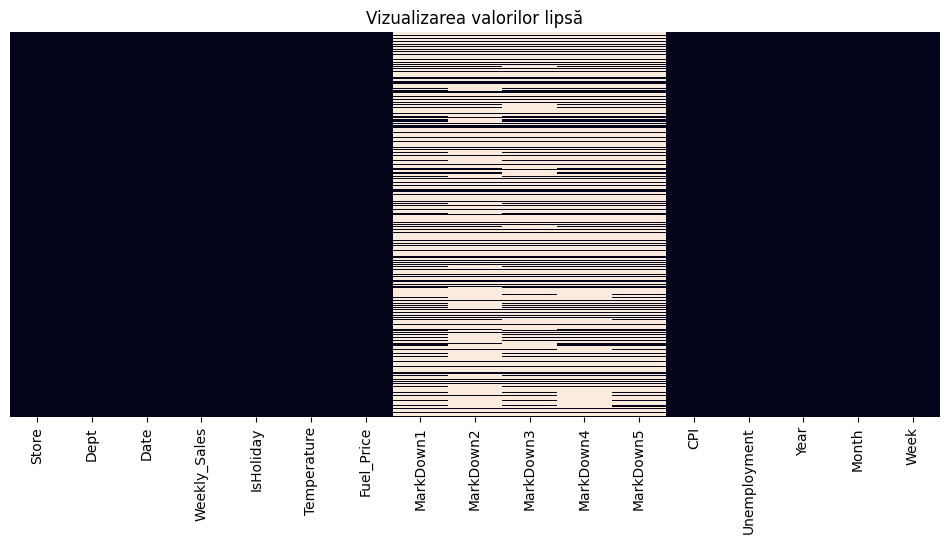

In [ ]:
# Vizualizarea valorilor lipsă
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Vizualizarea valorilor lipsă")
plt.show()

Vizualizarea grafică a valorilor lipsă confirmă că lipsurile sunt distribuite predominant în coloanele asociate promoțiilor comerciale, ceea ce sugerează că absența datelor nu este întâmplătoare, ci poate reflecta perioade în care anumite campanii promoționale nu au fost aplicate.

In [ ]:
# Valorile lipsă din MarkDown sunt înlocuite cu 0
# deoarece lipsa valorii poate indica lipsa unei promoții

markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [ ]:
# Pentru CPI și Unemployment folosim mediana
df["CPI"] = df["CPI"].fillna(df["CPI"].median())
df["Unemployment"] = df["Unemployment"].fillna(df["Unemployment"].median())

Datasetul conține valori lipsă în special pentru variabilele MarkDown.

Valorile lipsă pentru variabilele MarkDown au fost înlocuite cu 0 deoarece lipsa valorii poate sugera lipsa unei promoții.

Pentru variabilele CPI și Unemployment a fost utilizată mediana pentru imputare deoarece aceasta este mai robustă la valori extreme.

In [ ]:
# Verificare finală
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


Verificarea finală confirmă că setul de date nu mai conține valori lipsă, ceea ce asigură consistența și calitatea datelor pentru etapele ulterioare de analiză și modelare.

In [ ]:
features_cols = [
    "Store",
    "Dept",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "IsHoliday",
    "Year",
    "Month",
    "Week",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

X = df[features_cols]
y = df["Weekly_Sales"]

• Am definit setul variabilelor explicative utilizate în cadrul procesului de modelare pentru estimarea vânzărilor săptămânale.

• Am selectat variabile comerciale, economice și temporale relevante pentru surprinderea factorilor care influențează nivelul vânzărilor.

• Variabila dependentă utilizată în procesul de predicție este Weekly_Sales, reprezentând indicatorul estimat de modelul predictiv.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

În vederea evaluării corecte a performanței modelelor predictive setul de date a fost împărțit în seturi de antrenare și testare.

Proporția de 80% pentru antrenare și 20% pentru testare a fost aleasă deoarece reprezintă o metodă standard în machine learning, oferind un echilibru între capacitatea modelului de a învăța din date și posibilitatea evaluării performanței acestuia pe observații noi.


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

Modelul Random Forest a fost ales pentru identificarea relațiilor dintre factorii economici, sezonieri și promoționali care influențează nivelul vânzărilor.

Modelul Random Forest a fost antrenat pe datele de training și ulterior utilizat pentru generarea predicțiilor asupra setului de testare.


In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
MAE: 1580.36421172759
RMSE: 4129.369662914355
R2 Score: 0.9673007817387944


Performanța modelului Random Forest a fost evaluată utilizând indicatorii statistici MAE, RMSE și coeficientul de determinare R².
Rezultatele obținute evidențiază o capacitate ridicată de predicție a modelului, acesta înregistrând cele mai mici erori și cel mai ridicat nivel de acuratețe dintre toate metodele analizate.

Valoarea coeficientului R² de aproximativ 0.967 indică faptul că modelul explică aproximativ 96.7% din variația vânzărilor săptămânale. Totodată, valorile reduse ale indicatorilor MAE și RMSE confirmă faptul că predicțiile realizate sunt foarte apropiate de valorile reale observate.


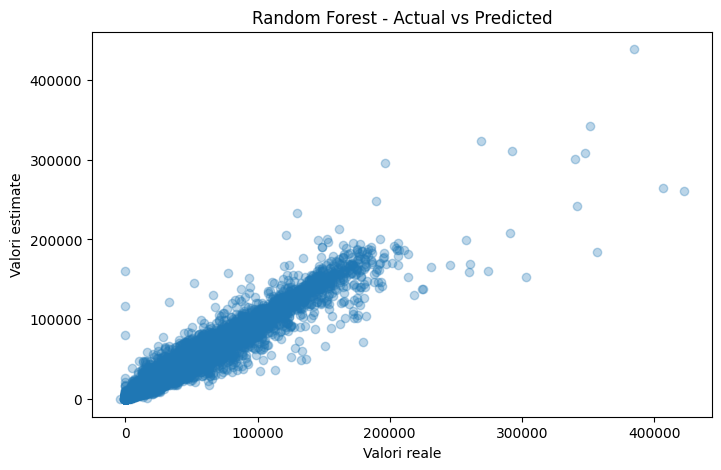

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Valori reale")
plt.ylabel("Valori estimate")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

Graficul comparativ dintre valorile reale și cele estimate evidențiază existența unei corelații puternice între predicțiile generate de model și valorile efective ale vânzărilor.

Distribuția majorității punctelor în apropierea diagonalei ideale indică un nivel ridicat de similaritate între valorile observate și cele prognozate, confirmând eficiența modelului Random Forest în modelarea relațiilor dintre variabilele analizate.

Totodată, se remarcă existența unor deviații în cazul valorilor extreme ale vânzărilor, aspect ce poate fi asociat cu fluctuațiile comerciale semnificative sau cu influența unor evenimente promoționale și sezoniere.


In [ ]:
sales_time = df.groupby("Date")["Weekly_Sales"].sum()
sales_time = sales_time.sort_index()

In [ ]:
train_size = int(len(sales_time) * 0.8)

train_arima = sales_time[:train_size]
test_arima = sales_time[train_size:]

In [ ]:
arima_model = ARIMA(train_arima, order=(5, 1, 0))
arima_result = arima_model.fit()

În vederea construirii modelului, valorile vânzărilor au fost structurate în funcție de succesiunea temporală, iar ulterior seria de date a fost împărțită într-un subset de antrenare și unul de testare, utilizate pentru evaluarea performanței predictive.

Pentru analiza și prognozarea vânzărilor săptămânale pe baza seriilor temporale a fost utilizat modelul ARIMA(5,1,0), ales datorită aplicabilității sale în modelarea datelor cronologice și în identificarea tendințelor de evoluție ale acestora.


In [ ]:
arima_pred = arima_result.forecast(steps=len(test_arima))

In [ ]:
mae_arima = mean_absolute_error(test_arima, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test_arima, arima_pred))
r2_arima = r2_score(test_arima, arima_pred)

print("ARIMA")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("R2 Score:", r2_arima)

ARIMA
MAE: 3597509.816665718
RMSE: 3924134.1172915758
R2 Score: -4.140609781162427


Performanța modelului ARIMA a fost evaluată utilizând indicatorii statistici MAE, RMSE și coeficientul de determinare R².
Rezultatele obținute indică o performanță redusă a modelului. Valoarea negativă a coeficientului R² sugerează faptul că modelul nu reușește să surprindă eficient structura datelor .


Performanța redusă a modelului poate fi explicată prin complexitatea seriei temporale a vânzărilor, caracterizată prin sezonalitate, fluctuații accentuate și influența simultană a mai multor factori externi, precum promoțiile, perioadele de sărbătoare și indicatorii economici. În aceste condiții, modelul ARIMA(5,1,0) nu reușește să surprindă în mod eficient dinamica datelor fără integrarea unor ajustări suplimentare sau a unor componente sezoniere specifice.


De asemenea, valorile foarte ridicate ale indicatorilor MAE și RMSE evidențiază existența unor erori semnificative de predicție. Acest comportament poate fi explicat prin faptul că seria temporală prezintă sezonalitate, variații puternice și influențe externe multiple, pe care modelul ARIMA nu le poate captura în mod eficient.


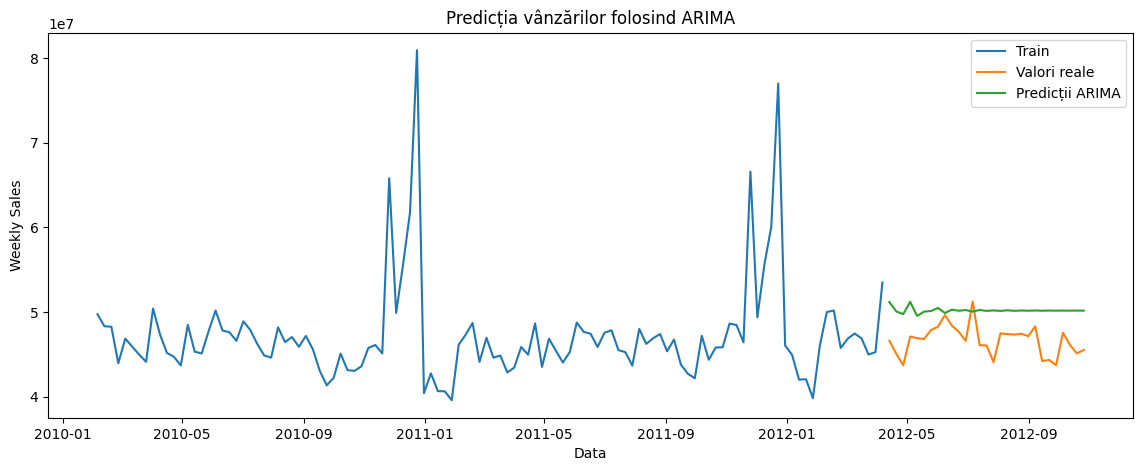

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train_arima.index, train_arima, label="Train")
plt.plot(test_arima.index, test_arima, label="Valori reale")
plt.plot(test_arima.index, arima_pred, label="Predicții ARIMA")
plt.title("Predicția vânzărilor folosind ARIMA")
plt.xlabel("Data")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

Compararea valorilor reale cu cele prognozate evidențiază diferențe semnificative între evoluția efectivă a vânzărilor și estimările generate de modelul ARIMA. Se observă faptul că predicțiile realizate urmează o evoluție relativ constantă, fără a reflecta fluctuațiile și variațiile accentuate existente în seria temporală analizată.


Valorile reale ale vânzărilor prezintă oscilații, determinate de influența factorilor sezonieri, economici și promoționali. În schimb, valorile estimate de model tind să se stabilizeze în jurul unei valori medii, ceea ce indică o capacitate redusă de adaptare la dinamica datelor.


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [ ]:
def evaluate_model(y_true, predictions, model_name):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 30)

In [ ]:
evaluate_model(y_test, linear_pred, "Linear Regression")
evaluate_model(y_test, tree_pred, "Decision Tree")
evaluate_model(y_test, rf_pred, "Random Forest")

Linear Regression
MAE: 15049.262678603758
RMSE: 22385.206379581796
R2 Score: 0.03906934134314477
------------------------------
Decision Tree
MAE: 2051.420587565529
RMSE: 5748.763814611313
R2 Score: 0.9366248825964296
------------------------------
Random Forest
MAE: 1580.36421172759
RMSE: 4129.369662914355
R2 Score: 0.9673007817387944
------------------------------


Pentru identificarea celui mai performant model de prognoză au fost analizate comparativ metodele Linear Regression, Decision Tree și Random Forest. Evaluarea a fost realizată prin intermediul indicatorilor MAE, RMSE și R² Score.

Modelul de regresie liniară a înregistrat cea mai slabă performanță dintre modelele de machine learning analizate. Valoarea foarte redusă a coeficientului R² (0.039) indică faptul că modelul explică doar aproximativ 3.9% din variația vânzărilor săptămânale. În plus, valorile ridicate ale MAE și RMSE sugerează că relația dintre variabile și vânzări nu este una strict liniară, ceea ce limitează capacitatea modelului de a realiza predicții precise.
Modelul Decision Tree a produs rezultate considerabil mai bune. Coeficientul R² de aproximativ 0.936 arată că modelul explică peste 93% din variația datelor. Reducerea semnificativă a erorilor MAE și RMSE demonstrează capacitatea arborilor de decizie de a surprinde relații neliniare și interacțiuni complexe între variabile.


Cel mai performant model a fost Random Forest:
•	cel mai mic MAE (1580),
•	cel mai mic RMSE (4129),
•	cel mai mare R² (0.967).

Rezultatele indică faptul că modelul explică aproximativ 96.7% din variația vânzărilor săptămânale, având o capacitate ridicată de generalizare. Performanța superioară se explică prin faptul că Random Forest combină predicțiile mai multor arbori de decizie, reducând riscul de overfitting și crescând stabilitatea estimărilor.Graficul „Actual vs Predicted” pentru Random Forest confirmă această performanță, deoarece majoritatea punctelor sunt concentrate în jurul diagonalei, ceea ce indică o concordanță ridicată între valorile reale și cele estimate.

Random Forest oferă cea mai mare acuratețe și poate fi considerat soluția optimă pentru predicția vânzărilor săptămânale în cadrul acestui set de date.



In [ ]:
ml_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, rf_pred)
    ]
})

ml_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,15049.262679,22385.206380,0.039069
1,Decision Tree,2051.420588,5748.763815,0.936625
2,Random Forest,1580.364212,4129.369663,0.967301


In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features_cols,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Dept,0.562535
0,Store,0.260897
4,CPI,0.061384
9,Week,0.034033
5,Unemployment,0.029886
2,Temperature,0.013073
12,MarkDown3,0.010325
14,MarkDown5,0.007413
3,Fuel_Price,0.006247
8,Month,0.005432


În cadrul procesului de selecție a caracteristicilor (feature selection), a fost utilizat algoritmul Random Forest Regressor pentru identificarea variabilelor cu cea mai mare contribuție în predicția valorii Weekly_Sales. Importanța fiecărei variabile a fost calculată pe baza contribuției acesteia la reducerea erorii în arborii de decizie ai modelului.

variabila Dept are cea mai mare influență asupra predicției vânzărilor săptămânale, având o importanță de aproximativ 56,25%. Acest rezultat sugerează că departamentul comercial reprezintă principalul factor explicativ al variației vânzărilor.

A doua variabilă relevantă este Store, cu o importanță de aproximativ 26,09%, ceea ce indică faptul că diferențele dintre magazine influențează semnificativ performanța vânzărilor.

Variabila CPI ocupă poziția a treia, însă cu o contribuție considerabil mai redusă (6,13%), sugerând că factorii macroeconomici au un impact moderat asupra valorii vânzărilor.

Variabile precum Week, Unemployment și Temperature prezintă influențe mai scăzute, dar variabilele de tip MarkDown, împreună cu Fuel_Price, Month, IsHoliday și Year, au o contribuție redusă în explicarea variației vânzărilor.


Analiza feature importance indică faptul că:
- localizarea și caracteristicile magazinelor influențează nivelul vânzărilor
- promoțiile au impact semnificativ asupra comportamentului consumatorilor



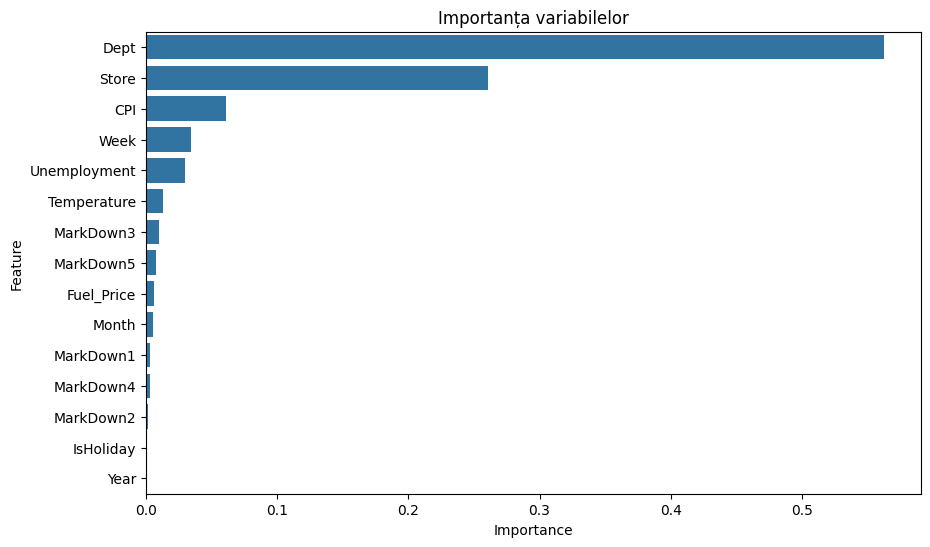

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title("Importanța variabilelor")
plt.show()

Vizualizarea grafică a importanței variabilelor facilitează evidențierea diferențelor dintre predictorii utilizați în model.

Graficul evidențiază distribuția neuniformă a importanței variabilelor în cadrul modelului Random Forest, subliniind predominanța variabilelor Dept și Store în procesul de predicție. Se remarcă o diferență considerabilă între contribuția acestor doi predictori și cea a celorlalte variabile incluse în model.

Aceste rezultate sugerează că performanța predictivă a modelului este influențată în principal de variabilele asociate structurii organizaționale a retailerului, respectiv departamentul și magazinul analizat.



In [ ]:
selected_features = feature_importance.head(10)["Feature"].tolist()

selected_features

['Dept',
 'Store',
 'CPI',
 'Week',
 'Unemployment',
 'Temperature',
 'MarkDown3',
 'MarkDown5',
 'Fuel_Price',
 'Month']

Au fost selectate primele 10 variabile cu cea mai mare importanță în cadrul modelului, pe baza valorilor obținute prin metoda feature importance

In [ ]:
X_selected = df[selected_features]
y = df["Weekly_Sales"]

A fost construit setul de variabile independente (X_selected) utilizând caracteristicile selectate anterior.

Variabila dependentă (y) a fost definită prin coloana Weekly_Sales, reprezentând valorile ce urmează a fi prezise.

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

Setul de date a fost împărțit în date de antrenare și date de testare prin utilizarea funcției train_test_split.

Proporția utilizată pentru împărțirea datelor a fost de 80% pentru antrenarea modelului și 20% pentru evaluarea performanței acestuia.

Parametrul random_state=42 a fost utilizat pentru a asigura reproductibilitatea rezultatelor obținute.

In [ ]:
rf_selected = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_selected.fit(X_train_sel, y_train_sel)
selected_pred = rf_selected.predict(X_test_sel)

A fost antrenat un model de tip Random Forest Regressor utilizând variabilele selectate în etapa de feature selection.

După procesul de antrenare, modelul a fost utilizat pentru generarea predicțiilor asupra setului de date destinat testării (X_test_sel).

In [ ]:
mae_selected = mean_absolute_error(y_test_sel, selected_pred)
rmse_selected = np.sqrt(mean_squared_error(y_test_sel, selected_pred))
r2_selected = r2_score(y_test_sel, selected_pred)

print("Random Forest cu feature selection")
print("MAE:", mae_selected)
print("RMSE:", rmse_selected)
print("R2 Score:", r2_selected)

Random Forest cu feature selection
MAE: 1580.7894026187823
RMSE: 4139.471170710957
R2 Score: 0.9671406045452582


Performanța modelului a fost evaluată prin intermediul indicatorilor statistici MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) și coeficientul de determinare R
2
.

Valoarea redusă a indicatorilor MAE și RMSE evidențiază un nivel scăzut al erorilor de predicție, ceea ce indică o acuratețe ridicată a modelului în estimarea valorilor variabilei dependente.
Rezultatele obținute evidențiază o capacitate ridicată de generalizare a modelului Random Forest, coeficientul de determinare R
2
=0.967 indicând faptul că aproximativ 96,7% din variația valorilor variabilei dependente (Weekly_Sales) este explicată de model.

In [ ]:
#Standardizare pentru regresie liniară
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

În cadrul modelului de regresie liniară, datele au fost standardizate prin utilizarea metodei StandardScaler, în scopul normalizării variabilelor de intrare și al eliminării diferențelor de scară dintre acestea.

Ulterior, a fost antrenat un model de regresie liniară pe datele standardizate, iar modelul a fost utilizat pentru generarea predicțiilor asupra setului de testare.

In [ ]:
linear_scaled = LinearRegression()

linear_scaled.fit(X_train_scaled, y_train)

scaled_pred = linear_scaled.predict(X_test_scaled)

In [ ]:
print("Linear Regression cu standardizare")
print("MAE:", mean_absolute_error(y_test, scaled_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, scaled_pred)))
print("R2 Score:", r2_score(y_test, scaled_pred))

Linear Regression cu standardizare
MAE: 15049.262678603536
RMSE: 22385.2063795818
R2 Score: 0.039069341343144215


Performanța modelului de regresie liniară a fost evaluată utilizând aceiași indicatori statistici, respectiv MAE, RMSE și coeficientul de determinare R
2
.

Valorile ridicate ale indicatorilor MAE și RMSE, precum și coeficientul de determinare redus (R
2
=0.039), indică o capacitate scăzută a modelului de regresie liniară de a explica variația variabilei dependente și de a realiza predicții precise.

In [ ]:
errors = y_test - rf_pred

Au fost calculate erorile de predicție prin determinarea diferenței dintre valorile reale și valorile estimate de modelul Random Forest.

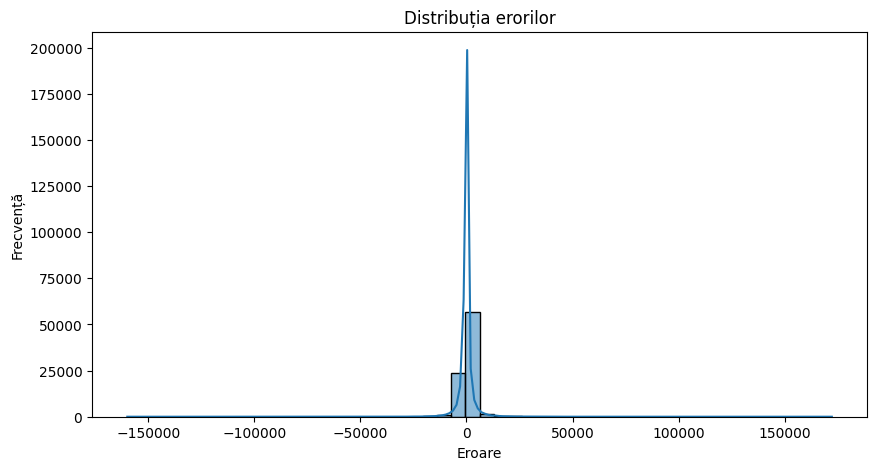

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=50, kde=True)
plt.title("Distribuția erorilor")
plt.xlabel("Eroare")
plt.ylabel("Frecvență")
plt.show()

• Majoritatea erorilor sunt concentrate în jurul valorii 0, ceea ce indică faptul că modelul realizează predicții apropiate de valorile reale.

• Distribuția prezintă un vârf central foarte pronunțat, sugerând o predominanță a erorilor de dimensiuni reduse.

• Se observă prezența unor cozi lungi atât în partea negativă, cât și în partea pozitivă a distribuției, ceea ce evidențiază existența unor cazuri extreme în care modelul generează erori foarte mari.

• Prezența acestor cozi lungi indică faptul că distribuția erorilor nu este normal distribuită, fiind influențată de outlieri și de variații semnificative între observații.

• Distribuția asimetrică sugerează că modelul nu generalizează uniform pentru toate exemplele din setul de date, existând anumite observații pentru care performanța predictivă este semnificativ mai redusă.



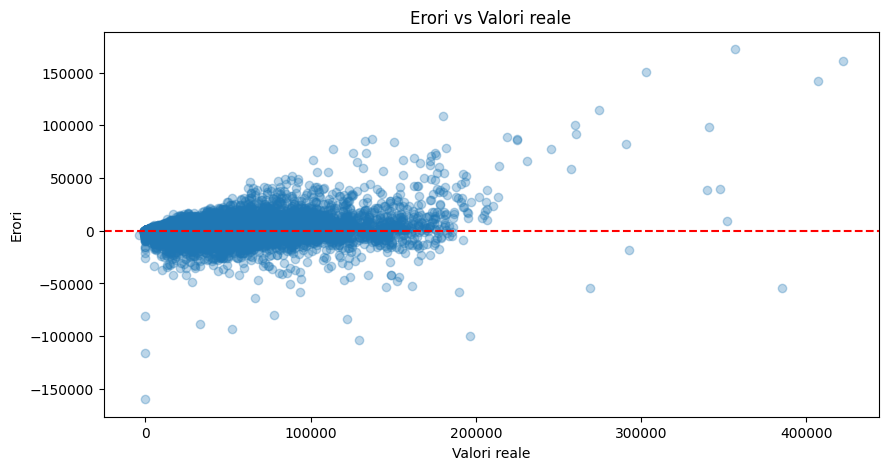

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, errors, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valori reale")
plt.ylabel("Erori")
plt.title("Erori vs Valori reale")
plt.show()


• Se observă o creștere progresivă a dispersiei erorilor odată cu creșterea valorilor reale, ceea ce sugerează existența heteroscedasticității.

• Pentru valorile reale reduse, erorile sunt distribuite pe un interval mai restrâns, în timp ce pentru valorile mari acestea prezintă o variabilitate semnificativ mai ridicată.


• Distribuția neuniformă a punctelor sugerează faptul că performanța modelului scade pentru valorile reale ridicate, unde estimările devin mai puțin stabile.

• Variabilitatea crescută a erorilor pentru valori mari indică faptul că modelul nu menține aceeași acuratețe pe întreg intervalul de date analizat.

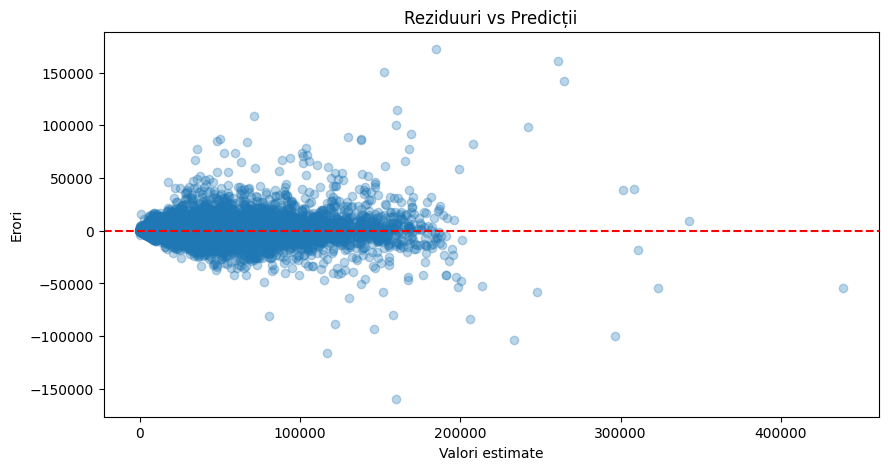

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(rf_pred, errors, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valori estimate")
plt.ylabel("Erori")
plt.title("Reziduuri vs Predicții")
plt.show()

• Punctele sunt concentrate în jurul liniei de referință corespunzătoare valorii 0, ceea ce indică faptul că modelul generează frecvent estimări apropiate de valorile reale.

• Odată cu creșterea valorilor estimate, amplitudinea reziduurilor devine mai ridicată, sugerând o creștere a variabilității erorilor.

• Lipsa unei dispersii uniforme în jurul valorii 0 indică faptul că ipoteza de homoscedasticitate nu este complet respectată. Forma distribuției punctelor indică prezența heteroscedasticității, întrucât dispersia reziduurilor nu rămâne constantă pe întreg intervalul analizat.

• Se observă existența unor observații extreme situate la distanțe mari față de linia de referință, ceea ce evidențiază cazuri în care modelul produce erori semnificative.

• Distribuția reziduurilor sugerează faptul că modelul are o performanță predictivă mai puțin stabilă pentru valorile estimate ridicate.



In [ ]:
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = rf_pred
error_df["Error"] = errors.values
error_df["Absolute_Error"] = np.abs(errors.values)

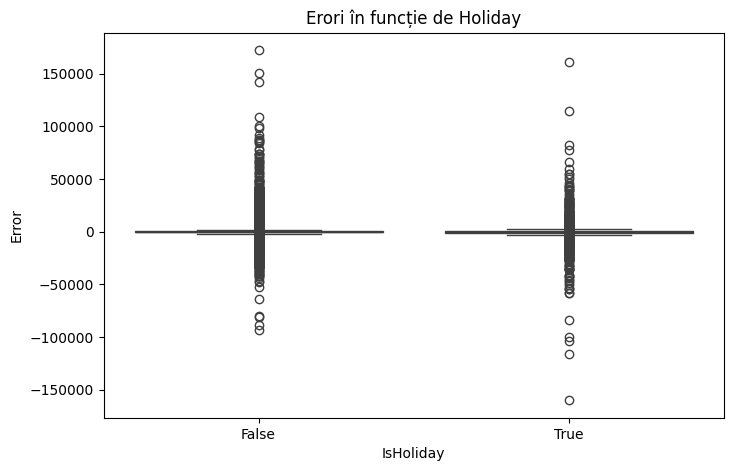

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="IsHoliday", y="Error", data=error_df)
plt.title("Erori în funcție de Holiday")
plt.show()

• Majoritatea erorilor sunt concentrate în jurul valorii 0 atât pentru zilele obișnuite, cât și pentru zilele de sărbătoare, ceea ce indică faptul că modelul realizează frecvent predicții apropiate de valorile reale

• Distribuția erorilor evidențiază prezența unui număr ridicat de valori extreme în ambele categorii.

• Se observă o dispersie ridicată a erorilor atât pentru categoria False, cât și pentru categoria True, ceea ce indică o variabilitate ridicată a performanței modelului.

• Valorile extreme sunt prezente atât în zona pozitivă, cât și în cea negativă a distribuției, evidențiind existența unor cazuri de supraestimare și subestimare accentuată.

• Distribuția similară a erorilor pentru cele două categorii sugerează faptul că variabila Holiday nu produce diferențe majore în comportamentul general al erorilor modelului.

• Prezența outlierilor indică dificultatea modelului de a surprinde complet anumite variații ale datelor, indiferent de existența unei zile de sărbătoare.

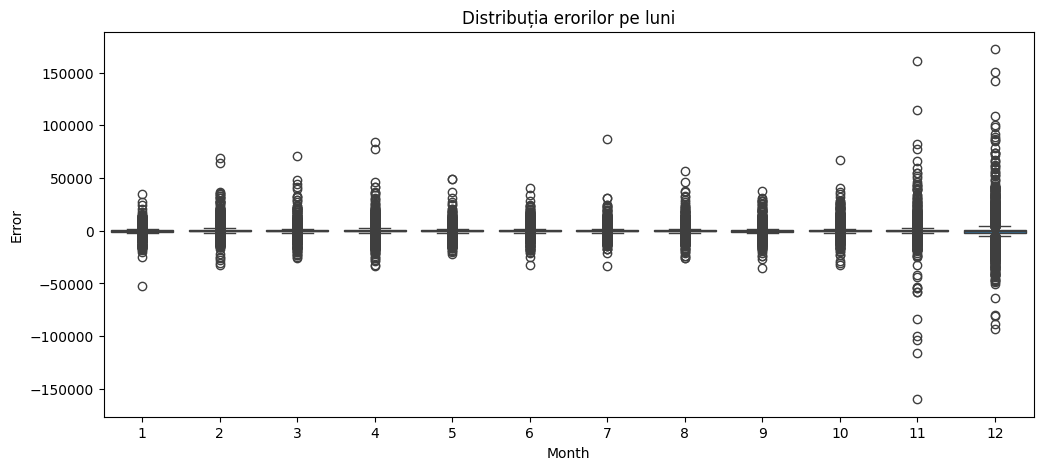

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(x="Month", y="Error", data=error_df)
plt.title("Distribuția erorilor pe luni")
plt.show()

• Distribuția erorilor diferă de la o lună la alta, evidențiind variații ale performanței modelului în funcție de perioada analizată.
• Pentru lunile 1–10, distribuțiile erorilor sunt mai restrânse, deși sunt prezente și în aceste cazuri anumite valori extreme izolat

• Lunile 11 și 12 prezintă cea mai mare dispersie a erorilor, evidențiind o variabilitate considerabil mai ridicată comparativ cu restul perioadei analizate.

• În luna 12 apar cele mai accentuate valori extreme, atât în zona pozitivă cât și în cea negativă, sugerând dificultăți ale modelului în estimarea observațiilor din perioada de sfârșit de an.


• Creșterea dispersiei erorilor în ultimele luni ale anului poate indica influența sezonalității sau a unor factori specifici acestei perioade care nu sunt surprinși de model.

• Prezența unui număr ridicat de outlieri evidențiază dificultatea modelului de a capta anumite situații atipice sau variații extreme ale datelor.

• Acuratețea predicțiilor scade în lunile 11 și 12, unde variabilitatea erorilor devine semnificativ mai ridicată.

In [ ]:
error_df.groupby("IsHoliday")["Absolute_Error"].mean()

,Absolute_Error
IsHoliday,
False,1493.554343
True,2716.288596


• Pentru categoria False, eroarea absolută medie este de aproximativ 1493.55, ceea ce indică faptul că modelul produce abateri relativ mai reduse în cazul zilelor care nu sunt sărbători.

• Pentru categoria True, eroarea absolută medie crește la aproximativ 2716.29, evidențiind faptul că modelul generează erori semnificativ mai mari în perioadele de sărbătoare.

• Rezultatele evidențiază faptul că modelul are o performanță mai stabilă pentru zilele obișnuite, în timp ce perioadele de sărbătoare reprezintă situații mai dificile pentru procesul de estimare

In [ ]:
error_df.groupby("Month")["Absolute_Error"].mean()

,Absolute_Error
Month,
1,1308.752786
2,1624.625292
3,1305.357933
4,1510.937936
5,1266.249997
6,1220.475279
7,1219.182331
8,1307.625449
9,1275.556038


• Rezultatele aferente erorii absolute medii indică variații temporale ale performanței predictive a modelului pe parcursul anului.

• În intervalul lunilor 1–10, valorile MAE se mențin la un nivel relativ apropiat, sugerând o stabilitate moderată a acurateței modelului în majoritatea perioadelor analizate.

• Cele mai reduse valori ale erorii absolute medii sunt observate în lunile 6 și 7, ceea ce evidențiază o capacitate predictivă mai ridicată în această perioadă.

• Luna 2 înregistrează cea mai ridicată valoare a MAE dintre primele zece luni, indicând o diminuare a preciziei estimărilor comparativ cu restul intervalului analizat.

• Se remarcă o creștere semnificativă a valorilor MAE în lunile 11 și 12, unde eroarea absolută medie atinge niveluri considerabil mai ridicate față de restul anului.

• Nivelul accentuat al erorilor în luna 12 sugerează dificultatea modelului de a surprinde în mod adecvat variațiile specifice perioadei de sfârșit de an.

• Creșterea progresivă a erorilor în ultimele luni poate indica influența unor factori sezonieri, a unor fluctuații accentuate ale datelor sau a unor comportamente atipice care nu sunt captate complet de model.


# Concluzii

În cadrul acestui proiect au fost analizate și modelate vânzările săptămânale ale companiei Walmart prin utilizarea metodelor statistice, econometrice și a algoritmilor de machine learning, având ca obiectiv identificarea principalilor factori care influențează nivelul vânzărilor și construirea unui model predictiv eficient.

Analiza exploratorie a datelor a evidențiat existența unor fluctuații importante ale vânzărilor, determinate în principal de sezonalitate, perioade festive și campanii promoționale. Distribuția variabilei Weekly_Sales a indicat o asimetrie pozitivă pronunțată, ceea ce sugerează existența unor perioade comerciale cu niveluri foarte ridicate ale cererii. Totodată, analiza comparativă dintre perioadele holiday și non-holiday a arătat că vânzările sunt considerabil mai mari și mai volatile în timpul sărbătorilor, confirmând impactul important al comportamentului sezonier al consumatorilor asupra performanței comerciale.

În urma analizei corelațiilor și a importanței variabilelor, s-a observat că factorii cu cea mai mare influență asupra nivelului vânzărilor sunt variabilele Dept și Store, ceea ce demonstrează faptul că diferențele dintre departamente și magazine influențează semnificativ performanța comercială. De asemenea, variabilele promoționale de tip MarkDown au evidențiat o influență pozitivă asupra vânzărilor, sugerând că reducerile și campaniile promoționale contribuie la stimularea cererii. În schimb, indicatorii macroeconomici precum CPI și Unemployment au avut un impact relativ redus asupra variației vânzărilor în perioada analizată.

Pentru estimarea vânzărilor au fost testate mai multe modele predictive, respectiv Linear Regression, Decision Tree, Random Forest și ARIMA. Rezultatele obținute au demonstrat superioritatea modelului Random Forest, acesta înregistrând cea mai bună performanță din punct de vedere al indicatorilor statistici utilizați pentru evaluare. Modelul a obținut un coeficient de determinare R² de aproximativ 0.967, ceea ce indică faptul că explică aproximativ 96,7% din variația vânzărilor săptămânale. Valorile reduse ale indicatorilor MAE și RMSE confirmă o capacitate ridicată de generalizare și o acuratețe foarte bună a predicțiilor realizate.

Rezultatele cercetării evidențiază utilitatea practică a unui astfel de model predictiv în activitatea unui retailer. Modelul poate contribui la prognozarea cererii, optimizarea stocurilor, planificarea promoțiilor și îmbunătățirea procesului decizional managerial. Estimarea corectă a nivelului vânzărilor permite reducerea costurilor operaționale, gestionarea mai eficientă a resurselor și adaptarea strategiilor comerciale în funcție de perioadele cu cerere ridicată.

Cu toate acestea, analiza a evidențiat și anumite limitări ale modelului. Performanța predictivă scade în perioadele caracterizate prin volatilitate ridicată, în special în lunile de sfârșit de an, unde apar variații accentuate ale comportamentului consumatorilor. De asemenea, existența unor outlieri și a heteroscedasticității sugerează faptul că anumite fluctuații ale datelor nu sunt surprinse complet de model. În acest context, cercetările viitoare pot include utilizarea unor modele mai avansate de forecasting și integrarea unor variabile suplimentare pentru îmbunătățirea performanței predictive.



---

